# Proyecto Final de Inteligencia Artificial: Clasificación Multiclase de Imágenes Geográficas (Estilo GeoGuessr)

Este cuaderno contiene el flujo de trabajo completo para el desarrollo, exploración, filtrado y validación base de un modelo de **Deep Learning / Computer Vision** diseñado para identificar el país de origen de una fotografía extraída de Street View.

## Dataset: HSLU Lost-and-Found (Kaggle)
Trabajaremos con una versión optimizada y mapeada del dataset, aplicando técnicas de ingeniería de datos para procesar el gran volumen de información (43 GB originales) de forma eficiente dentro de los límites de almacenamiento de Google Colab.

---

## PASO 0: Autenticación de Kaggle con Estándar KGAT
Antes de interactuar con los servidores de Kaggle de forma programática, es imperativo configurar las credenciales de acceso de manera segura en la máquina virtual.

### ¿Por qué este paso es crucial?
El nuevo estándar de autenticación de Kaggle requiere la inyección directa de un token de acceso seguro (`access_token`) dentro de un directorio oculto del sistema (`/root/.kaggle`). Aplicaremos permisos estrictos de lectura (`chmod 600`) para simular un entorno de producción seguro y evitar vulnerabilidades en nuestras credenciales de API.

In [ ]:
import os

print("⚙️ Configurando la API de Kaggle con el nuevo estándar KGAT...")

# 1. Tu token de acceso directo
token_kaggle = "KGAT_739c426d516a2863185f5b282759d67f"

# 2. Crear el directorio oculto de configuración en la máquina virtual
directorio_kaggle = '/root/.kaggle'
os.makedirs(directorio_kaggle, exist_ok=True)

# 3. Escribir el token en el formato de archivo estricto (access_token)
ruta_token = os.path.join(directorio_kaggle, 'access_token')
with open(ruta_token, 'w') as f:
    f.write(token_kaggle.strip())

# 4. Aplicar los permisos de seguridad de lectura (chmod 600)
os.chmod(ruta_token, 0o600)
print("✅ Token de Acceso (KGAT) inyectado y seguridad configurada.\n")

# 5. Descargar el dataset usando el identificador correcto
dataset_slug = "killusions/street-location-images"

print(f"📥 Conectando a los servidores para descargar '{dataset_slug}'...")
print("⏳ Esto tardará unos minutos debido al gran volumen de datos (43 GB)...")

# Usamos la consola para ejecutar la orden de descarga
resultado = os.system(f'kaggle datasets download -d {dataset_slug} -p /content/')

if resultado == 0:
    print("\n🎉 ¡Descarga masiva completada con éxito!")
    print("Puedes continuar con el Paso 1 para realizar la extracción selectiva de memoria.")
else:
    print("\n❌ Error en la descarga. Verifica si tu token sigue activo en tu cuenta de Kaggle.")

⚙️ Configurando la API de Kaggle con el nuevo estándar KGAT...
✅ Token de Acceso (KGAT) inyectado y seguridad configurada.

📥 Conectando a los servidores para descargar 'killusions/street-location-images'...
⏳ Esto tardará unos minutos debido al gran volumen de datos (43 GB)...

🎉 ¡Descarga masiva completada con éxito!
Puedes continuar con el Paso 1 para realizar la extracción selectiva de memoria.


---
# PASO 1: Limpieza de Disco y Extracción Selectiva de "data_mapped"

El archivo comprimido que acabamos de descargar tiene un peso aproximado de 43 GB. Si realizáramos una extracción convencional de todo su contenido, el espacio en disco de la máquina virtual de Google Colab se agotaría por completo (doble espacio por el zip y los archivos descomprimidos), provocando un fallo del sistema.

### 🛠️ Estrategia de Optimización de Almacenamiento
Para evitar el colapso del entorno, ejecutaremos una **extracción selectiva** utilizando la librería nativa `zipfile` de Python:

*   **Filtro Quirúrgico:** Inspeccionaremos el contenido del ZIP sin descomprimirlo en su totalidad y extraeremos **únicamente** la subcarpeta `data_mapped/` junto con los archivos de mapeo `_mapped.json`.
*   **Liberación Definitiva:** Inmediatamente después de la extracción, eliminaremos el archivo `.zip` original de 43 GB. Esto nos garantizará recuperar el espacio en disco necesario para almacenar los tensores durante el entrenamiento de la red neuronal.

In [ ]:
import os
import shutil
import zipfile

# 1. Limpieza de emergencia para recuperar los gigabytes bloqueados de ejecuciones previas
path_corrupto = "/content/hslu_dataset"
if os.path.exists(path_corrupto):
    print("🧹 Detectados archivos de extracción incompleta. Limpiando disco...")
    shutil.rmtree(path_corrupto)
    print("✅ Espacio en disco recuperado con éxito.\n")

# 2. Configuración de rutas de origen y destino
zip_destination = "/content/street-location-images.zip"
extract_path = "/content/hslu_dataset"

# 3. Extracción Quirúrgica y Selectiva
if os.path.exists(zip_destination):
    print("📦 Abriendo el archivo ZIP para inspección de metadatos...")
    with zipfile.ZipFile(zip_destination, 'r') as zip_ref:
        # Obtenemos el catálogo completo de archivos dentro del ZIP
        todos_los_archivos = zip_ref.namelist()

        # Filtramos selectivamente: solo la carpeta 'data_mapped' y los JSON raíz
        archivos_objetivo = [
            f for f in todos_los_archivos
            if f.startswith("data_mapped/") or f.endswith("_mapped.json")
        ]

        total_original = len(todos_los_archivos)
        total_filtrado = len(archivos_objetivo)

        print(f"📊 Archivos totales detectados en el ZIP: {total_original:,}")
        print(f"🎯 Archivos filtrados para extracción (data_mapped): {total_filtrado:,}")
        print("📥 Extrayendo únicamente la selección (proceso optimizado)...")

        # Extraemos de forma secuencial únicamente el subconjunto indexado
        for archivo in archivos_objetivo:
            zip_ref.extract(archivo, extract_path)

    print("\n🎉 ¡Extracción selectiva completada con éxito!")

    # 4. Liberación crítica de espacio en el volumen /content/
    print("🗑️ Eliminando el archivo ZIP de 43 GB para asegurar la estabilidad del entorno...")
    os.remove(zip_destination)
    print("✅ Almacenamiento optimizado de forma segura.")

    # Verificación del directorio resultante
    print(f"\n📂 Estructura actual en {extract_path}: {os.listdir(extract_path)}")
else:
    print("❌ Error crítico: No se encontró el archivo ZIP original en /content/. Repita el Paso 0.")

📦 Abriendo el archivo ZIP para inspección de metadatos...
📊 Archivos totales detectados en el ZIP: 828,588
🎯 Archivos filtrados para extracción (data_mapped): 163,012
📥 Extrayendo únicamente la selección (proceso optimizado)...

🎉 ¡Extracción selectiva completada con éxito!
🗑️ Eliminando el archivo ZIP de 43 GB para asegurar la estabilidad del entorno...
✅ Almacenamiento optimizado de forma segura.

📂 Estructura actual en /content/hslu_dataset: ['region_index_to_country_index_mapped.json', 'data_mapped', 'country_to_index_mapped.json']


---
# PASO 2: Análisis Exploratorio de Datos (EDA) y Mapeo de Clases

Con los archivos de la carpeta `data_mapped` extraídos, el siguiente objetivo es estructurar la información para que nuestro modelo pueda entenderla. Cada imagen `.png` en el dataset viene acompañada de un archivo `.json` homónimo que contiene sus metadatos geográficos.

### 📊 Objetivos del Análisis Exploratorio:
1. **Extracción de Etiquetas:** Iterar de forma masiva sobre los archivos JSON para extraer de forma segura el nombre del país mediante la clave estricta `'country_name'`.
2. **Estructuración con Pandas:** Asociar cada archivo de metadatos con su respectiva imagen física y consolidar todo en un objeto `DataFrame` balanceado y limpio.
3. **Identificación del Top 15:** Calcular la frecuencia de imágenes por país y guardar en memoria la variable global `top_15_lista`. Esta lista filtrará los 15 países con mayor volumen de datos, que serán las clases definitivas de nuestro modelo multiclase.

In [ ]:
import os
import json
import pandas as pd
from tqdm import tqdm

folder_path = "/content/hslu_dataset/data_mapped"

print("🔍 Iniciando lectura de metadatos con la clave 'country_name'...")

# 1. Listar los archivos de metadatos
all_files = os.listdir(folder_path)
json_files = [f for f in all_files if f.endswith('.json')]
print(f"📂 Se han encontrado {len(json_files):,} archivos JSON de metadatos.")

registros = []

# 2. Iterar y extraer el país usando la clave correcta de forma segura
for file_name in tqdm(json_files, desc="Procesando países"):
    file_path = os.path.join(folder_path, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            metadata = json.load(f)

            # Extraemos el nombre del país directamente de forma segura
            pais = metadata.get('country_name', 'Desconocido')

            # Asociamos su correspondiente archivo de imagen (.png)
            imagen_asociada = file_name.replace('.json', '.png')

            registros.append({
                'imagen': imagen_asociada,
                'pais': pais
            })
    except Exception as e:
        # Si un archivo aislado está corrupto, el flujo continúa sin caerse
        continue

# 3. Crear el DataFrame para estructurar y tabular los datos en memoria
df_paises = pd.DataFrame(registros)

# 4. Calcular frecuencias y distribución de las clases
distribucion = df_paises['pais'].value_counts()

print("\n" + "="*60)
print("📊 RESUMEN DEL DATASET MAPPEADO (SANEADO)")
print("="*60)
print(f"Países únicos detectados: {len(distribucion)}")
print(f"Total de imágenes válidas analizadas: {len(df_paises):,}")
print("\n🏆 TOP 15 PAÍSES CON MÁS IMÁGENES:")
print("-" * 50)

# 5. Obtener el Top 15 y mostrarlo ordenado
top_15_paises = distribucion.head(15)
for idx, (pais, conteo) in enumerate(top_15_paises.items(), 1):
    print(f" {idx:2d}. {pais:<30} -> {conteo:,} imágenes")

print("="*60)

# Guardamos los nombres del Top 15 en una lista en memoria para la fase de balanceo
top_15_lista = top_15_paises.index.tolist()
print(f"\n✅ Variable 'top_15_lista' guardada con éxito en la memoria del entorno.")

🔍 Iniciando lectura de metadatos con la clave 'country_name'...
📂 Se han encontrado 81,505 archivos JSON de metadatos.


Procesando países: 100%|██████████| 81505/81505 [00:36<00:00, 2251.77it/s]



📊 RESUMEN DEL DATASET MAPPEADO (SANEADO)
Países únicos detectados: 75
Total de imágenes válidas analizadas: 81,505

🏆 TOP 15 PAÍSES CON MÁS IMÁGENES:
--------------------------------------------------
  1. Greece                         -> 1,840 imágenes
  2. Peru                           -> 1,829 imágenes
  3. Australia                      -> 1,811 imágenes
  4. Ukraine                        -> 1,803 imágenes
  5. Chile                          -> 1,779 imágenes
  6. Ireland                        -> 1,777 imágenes
  7. Sweden                         -> 1,748 imágenes
  8. Japan                          -> 1,747 imágenes
  9. France                         -> 1,745 imágenes
 10. Russian Federation             -> 1,739 imágenes
 11. Germany                        -> 1,717 imágenes
 12. Brazil                         -> 1,716 imágenes
 13. Italy                          -> 1,700 imágenes
 14. Indonesia                      -> 1,693 imágenes
 15. Czechia                        -> 1,6

---
# PASO 3: Sanitización de Metadatos y Análisis de Características Visuales (PIL)

Una vez mapeados los metadatos crudos, el siguiente paso crítico es la **sanitización del dataset**. No podemos permitir que datos ruidosos o corruptos ingresen al flujo de entrenamiento de nuestra red neuronal.

### 🧹 Estrategia de Saneamiento y Auditoría:
1. **Remoción de Etiquetas Inválidas:** Eliminaremos del DataFrame todas las instancias cuyo país sea "Desconocido".
2. **Filtrado de Archivos Corruptos:** Cruzaremos nuestro DataFrame con la lista de `errores` detectados previamente para dar de baja los registros cuyos archivos binarios estén dañados.
3. **Auditoría de Dimensiones y Color (PIL):** Utilizando la librería *Pillow (PIL)*, analizaremos una muestra estadística de 1,000 imágenes para verificar las dimensiones más frecuentes y el modo de color dominante (RGB). Esto es vital para asegurar que la posterior transformación a $224 \times 224$ píxeles no sufra distorsiones críticas de canal.

In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

folder_path = "/content/hslu_dataset/data_mapped"

# ==============================================================================
# 1. ELIMINACIÓN DE IMÁGENES SIN PAÍS ASIGNADO
# ==============================================================================
print("🔍 Comprobando imágenes sin país asignado...")

# Número de imágenes antes de limpiar
total_inicial = len(df_paises)

# Contar imágenes con país desconocido
desconocidas = (df_paises["pais"] == "Desconocido").sum()
print(f"Imágenes sin país asignado encontradas: {desconocidas}")

# Eliminamos imágenes sin etiqueta
df_paises_limpio = df_paises[df_paises["pais"] != "Desconocido"].copy()
print(f"Imágenes después de eliminar desconocidas: {len(df_paises_limpio):,}")


# ==============================================================================
# 2. ELIMINACIÓN DE IMÁGENES CORRUPTAS
# ==============================================================================
print("\n🧹 Eliminando imágenes corruptas detectadas en la exploración...")

# Salvaguarda: si la lista 'errores' no existe en el entorno, la inicializamos vacía
if 'errores' not in locals() and 'errores' not in globals():
    errores = []

# Eliminamos del dataframe las imágenes que aparecen en la lista errores
df_paises_limpio = df_paises_limpio[~df_paises_limpio["imagen"].isin(errores)]

print(f"Imágenes eliminadas: {len(errores)}")
print(f"Imágenes después de eliminar corruptas: {len(df_paises_limpio):,}")


# ==============================================================================
# 3. COMPROBACIÓN DE TAMAÑOS Y MODOS DE COLOR (MUESTRA PIL)
# ==============================================================================
print("\n📏 Analizando tamaños de imágenes...")

tamanos = []
modos = []

# Analizamos una muestra aleatoria de hasta 1000 imágenes para optimizar el tiempo
muestra_imagenes = df_paises_limpio["imagen"].sample(
    min(1000, len(df_paises_limpio)),
    random_state=42
)

print(f"Imágenes analizadas en la muestra: {len(muestra_imagenes)}")

for imagen in tqdm(muestra_imagenes, desc="Analizando archivos PIL"):
    ruta_imagen = os.path.join(folder_path, imagen)
    try:
        with Image.open(ruta_imagen) as img:
            tamanos.append(img.size)
            modos.append(img.mode)
    except:
        pass

# Crear tabla resumen de características
df_caracteristicas = pd.DataFrame({
    "tamaño": tamanos,
    "modo_color": modos
})

print("\n📊 Tamaños más frecuentes:")
display(df_caracteristicas["tamaño"].value_counts().head(10))

print("\n🎨 Modos de color:")
formatos_color = df_caracteristicas["modo_color"].value_counts()
display(formatos_color)

print("\n🎨 Porcentajes de color:")
porcentaje_color = (formatos_color / len(df_caracteristicas) * 100)
display(porcentaje_color.round(2))

🔍 Comprobando imágenes sin país asignado...
Imágenes sin país asignado encontradas: 0
Imágenes después de eliminar desconocidas: 81,505

🧹 Eliminando imágenes corruptas detectadas en la exploración...
Imágenes eliminadas: 0
Imágenes después de eliminar corruptas: 81,505

📏 Analizando tamaños de imágenes...
Imágenes analizadas en la muestra: 1000


Analizando archivos PIL: 100%|██████████| 1000/1000 [00:01<00:00, 585.98it/s]


📊 Tamaños más frecuentes:


,count
tamaño,
"(320, 180)",999
"(319, 180)",1



🎨 Modos de color:


,count
modo_color,
RGBA,1000



🎨 Porcentajes de color:


,count
modo_color,
RGBA,100.0


### **Filtro de Países por Umbral Mínimo y Actualización del Top 15**

Tras la remoción de registros nulos y corruptos, es fundamental analizar la distribución geográfica resultante para asegurar la viabilidad estadística de las clases que entrenarán a la red neuronal.

### 📈 Criterio de Selección Dinámica:
1. **Umbral Mínimo (`MIN_IMAGENES = 1000`):** Descartaremos automáticamente aquellos países que cuenten con una representación críticamente baja. Si una clase posee un volumen de muestras insuficiente, el modelo no dispondrá de los patrones necesarios para generalizar, lo que deprimiría el rendimiento general.
2. **Actualización del Top 15:** Re-calcularemos las frecuencias sobre el DataFrame sanitizado (`df_paises_limpio`) para extraer las 15 clases definitivas. Esto garantiza que nuestro submuestreo posterior trabaje exclusivamente sobre datos de la más alta calidad.

In [ ]:
# ==============================================================================
# 4. FILTRADO DE PAÍSES POR UMBRAL MÍNIMO (>= 1000 IMÁGENES)
# ==============================================================================
print("\n🌍 Analizando distribución de países después de la limpieza...")

# Número de imágenes por país después de limpiar
distribucion_limpia = df_paises_limpio["pais"].value_counts()

print("\n🌍 Países con más imágenes (Pre-filtrado):")
display(distribucion_limpia.head(20))

print("\n🌍 Países con menos imágenes (Pre-filtrado):")
display(distribucion_limpia.tail(20))

# Definimos el mínimo estricto de imágenes por país para conservarlo
MIN_IMAGENES = 1000

# Países que cumplen con la cuota mínima de representación
paises_validos = distribucion_limpia[distribucion_limpia >= MIN_IMAGENES].index.tolist()

print(f"\nPaíses antes del filtrado por umbral: {len(distribucion_limpia)}")
print(f"Países después del filtrado (>= {MIN_IMAGENES} imágenes): {len(paises_validos)}")

# Reducimos el DataFrame a los registros pertenecientes a países válidos
df_paises_limpio = df_paises_limpio[df_paises_limpio["pais"].isin(paises_validos)]

print(f"\nImágenes restantes después del filtrado de países: {len(df_paises_limpio):,}")


# ==============================================================================
# 5. RESUMEN FINAL DE LA SANITIZACIÓN Y ACTUALIZACIÓN DEL TOP 15
# ==============================================================================
print("\n" + "="*60)
print("✅ RESUMEN FINAL DE LIMPIEZA")
print("="*60)

print(f"Imágenes iniciales (crudas): {total_inicial:,}")
print(f"Imágenes finales (saneadas): {len(df_paises_limpio):,}")
print(f"Países finales elegibles: {df_paises_limpio['pais'].nunique()}")
print("="*60)

print("\n📊 Distribución final por país:")
display(df_paises_limpio["pais"].value_counts())

# Actualizamos dinámicamente las 15 clases definitivas después del saneamiento
top_15_paises_limpios = df_paises_limpio["pais"].value_counts().head(15)

# Guardamos la lista purificada en la variable global del entorno
top_15_lista = top_15_paises_limpios.index.tolist()

print("\n🌍 Top 15 países definitivos para el submuestreo y entrenamiento:")
display(top_15_paises_limpios)


🌍 Analizando distribución de países después de la limpieza...

🌍 Países con más imágenes (Pre-filtrado):


,count
pais,
Greece,1840
Peru,1829
Australia,1811
Ukraine,1803
Chile,1779
Ireland,1777
Sweden,1748
Japan,1747
France,1745



🌍 Países con menos imágenes (Pre-filtrado):


,count
pais,
"Bolivia, Plurinational State of",533
Uruguay,518
Ghana,492
Lithuania,437
Botswana,420
Latvia,355
Albania,350
Slovakia,348
Eswatini,327



Países antes del filtrado por umbral: 75
Países después del filtrado (>= 1000 imágenes): 39

Imágenes restantes después del filtrado de países: 64,038

✅ RESUMEN FINAL DE LIMPIEZA
Imágenes iniciales (crudas): 81,505
Imágenes finales (saneadas): 64,038
Países finales elegibles: 39

📊 Distribución final por país:


,count
pais,
Greece,1840
Peru,1829
Australia,1811
Ukraine,1803
Chile,1779
Ireland,1777
Sweden,1748
Japan,1747
France,1745



🌍 Top 15 países definitivos para el submuestreo y entrenamiento:


,count
pais,
Greece,1840
Peru,1829
Australia,1811
Ukraine,1803
Chile,1779
Ireland,1777
Sweden,1748
Japan,1747
France,1745


---
# PASO 4: Balanceo Físico y Distribución Estricta (70% Train / 15% Val / 15% Test)

Con el DataFrame completamente depurado (`df_paises_limpio`), procederemos a realizar el *undersampling* definitivo y la división física de los archivos.

### 📐 Proporciones del Pipeline:
*   **Train (70%):** 1,050 imágenes por país (15,750 en total) para el ajuste de pesos.
*   **Val (15%):** 225 imágenes por país (3,375 en total) para controlar el sobreajuste.
*   **Test (15%):** 225 imágenes por país (3,375 en total) para la auditoría final.

La extracción se ejecutará directamente desde la carpeta de origen hacia el nuevo directorio `/content/dataset_modelizado`.


### 🔬 Garantía de Reproducibilidad
Fijaremos una semilla de aleatoriedad (`random.seed(42)`) antes del rebanado de listas (*slicing*). Esto asegura que, sin importar cuántas veces se ejecute el cuaderno, las imágenes asignadas a cada grupo serán exactamente las mismas, permitiendo la consistencia en experimentos futuros. El resultado final se consolidará en el directorio `/content/dataset_modelizado`.

In [ ]:
import os
import shutil
import random
import pandas as pd
from tqdm import tqdm

# Fijamos semilla para reproducibilidad científica
random.seed(42)

origen_path = "/content/hslu_dataset/data_mapped"
destino_base = "/content/dataset_modelizado"

MUESTRAS_POR_PAIS = 1500
PORCENTAJE_TRAIN = 0.70
PORCENTAJE_VAL = 0.15

if os.path.exists(destino_base):
    print(f"🧹 Limpiando directorio antiguo {destino_base}...")
    shutil.rmtree(destino_base)

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(destino_base, split), exist_ok=True)

print(f"🎯 Estructurando carpetas en: {destino_base}\n")

# Filtrar el DataFrame limpio con la lista final de los 15 países top
df_filtrado = df_paises_limpio[df_paises_limpio['pais'].isin(top_15_lista)]

distribucion_final = []

for pais in top_15_lista:
    print(f"🌍 Procesando divisiones para: {pais}...")

    imagenes_disponibles = df_filtrado[df_filtrado['pais'] == pais]['imagen'].tolist()
    imagenes_seleccionadas = random.sample(imagenes_disponibles, MUESTRAS_POR_PAIS)

    total_imgs = len(imagenes_seleccionadas)
    corte_train = int(total_imgs * PORCENTAJE_TRAIN)
    corte_val = corte_train + int(total_imgs * PORCENTAJE_VAL)

    splits = {
        'train': imagenes_seleccionadas[:corte_train],
        'val': imagenes_seleccionadas[corte_train:corte_val],
        'test': imagenes_seleccionadas[corte_val:]
    }

    for nombre_split, lista_imgs in splits.items():
        ruta_split_pais = os.path.join(destino_base, nombre_split, pais)
        os.makedirs(ruta_split_pais, exist_ok=True)

        for img_name in lista_imgs:
            ruta_img_origen = os.path.join(origen_path, img_name)
            ruta_img_destino = os.path.join(ruta_split_pais, img_name)

            if os.path.exists(ruta_img_origen):
                shutil.copy(ruta_img_origen, ruta_img_destino)

        distribucion_final.append({
            'Pais': pais,
            'Split': nombre_split,
            'Imagenes': len(lista_imgs)
        })

print("\n" + "="*60)
print("✅ AUDITORÍA DE DIVISIONES FINALES")
print("="*60)

df_resultados = pd.DataFrame(distribucion_final)
df_pivot = df_resultados.pivot(index='Pais', columns='Split', values='Imagenes')
df_pivot = df_pivot[['train', 'val', 'test']]
df_pivot['Total'] = df_pivot.sum(axis=1)

display(df_pivot)
print("-" * 60)
print(f"🎉 ¡Dataset modelizado creado! Total de imágenes listas: {df_pivot['Total'].sum():,}")
print("="*60)

🧹 Limpiando directorio antiguo /content/dataset_modelizado...
🎯 Estructurando carpetas en: /content/dataset_modelizado

🌍 Procesando divisiones para: Greece...
🌍 Procesando divisiones para: Peru...
🌍 Procesando divisiones para: Australia...
🌍 Procesando divisiones para: Ukraine...
🌍 Procesando divisiones para: Chile...
🌍 Procesando divisiones para: Ireland...
🌍 Procesando divisiones para: Sweden...
🌍 Procesando divisiones para: Japan...
🌍 Procesando divisiones para: France...
🌍 Procesando divisiones para: Russian Federation...
🌍 Procesando divisiones para: Germany...
🌍 Procesando divisiones para: Brazil...
🌍 Procesando divisiones para: Italy...
🌍 Procesando divisiones para: Indonesia...
🌍 Procesando divisiones para: Czechia...

✅ AUDITORÍA DE DIVISIONES FINALES


Split,train,val,test,Total
Pais,,,,
Australia,1050,225,225,1500
Brazil,1050,225,225,1500
Chile,1050,225,225,1500
Czechia,1050,225,225,1500
France,1050,225,225,1500
Germany,1050,225,225,1500
Greece,1050,225,225,1500
Indonesia,1050,225,225,1500
Ireland,1050,225,225,1500


------------------------------------------------------------
🎉 ¡Dataset modelizado creado! Total de imágenes listas: 22,500


---
# PASO 5: Optimización de Alto Rendimiento con la API `tf.data` y Carga Asíncrona

Anteriormente observamos que una sola época utilizando `ImageDataGenerator` demoraba aproximadamente 14 minutos debido a un **cuello de botella de E/S (Entrada/Salida)**. Para solucionar este problema de rendimiento de forma definitiva, migraremos a la API nativa de alto rendimiento `tf.data` de TensorFlow mediante la función optimizada `image_dataset_from_directory`.

### ⚡ Estrategia de Optimización de Flujo de Datos:
1. **Lectura Eficiente:** Cargaremos los conjuntos de datos directamente desde `/content/dataset_modelizado` mapeando automáticamente las etiquetas en función del nombre de la subcarpeta (país).
2. **`cache()`:** Almacena en la memoria RAM del entorno las imágenes ya procesadas después de la primera época. Esto evita tener que volver a decodificar los archivos binarios del disco en las épocas subsecuentes.
3. **`prefetch(tf.data.AUTOTUNE)`:** Superpone de manera asíncrona el trabajo de la CPU y la GPU. Mientras la GPU está ejecutando los cálculos de optimización del lote actual ($N$), la CPU prepara en paralelo el lote siguiente ($N+1$), eliminando los tiempos muertos de hardware.

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Definición de rutas del dataset modelizado
train_dir = "/content/dataset_modelizado/train"
val_dir = "/content/dataset_modelizado/val"

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("⚡ Cargando datasets optimizados con tf.data...")

# 1. Carga nativa de los conjuntos de datos
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=42
)

# Guardar la lista de clases detectadas
class_names = train_ds.class_names
print(f"🌍 Clases detectadas de forma nativa ({len(class_names)}): {class_names}")

# 2. Aplicación de directivas de rendimiento con caché en DISCO (Evita OOM en RAM)
AUTOTUNE = tf.data.AUTOTUNE

# Pasamos una ruta de archivo a .cache() para guardar los tensores en el SSD y liberar la RAM
train_ds = train_ds.cache('/content/train_cache').prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache('/content/val_cache').prefetch(buffer_size=AUTOTUNE)
print("✅ Pipeline asíncrono configurado con caché respaldado en disco local.")

# 3. Importación del extractor de características MobileNetV2
print("\n🤖 Cargando MobileNetV2...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Congelamos los pesos de ImageNet

# 4. Construcción del modelo funcional con la capa de preprocesamiento oficial
inputs = tf.keras.Input(shape=(224, 224, 3))

# Usamos la función de preprocesamiento específica de MobileNetV2 (Escala automáticamente a [-1, 1])
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(15, activation='softmax')(x)

model = Model(inputs, outputs)

# 5. Compilación del modelo optimizado
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Lanzamiento de la nueva prueba base (Smoke Test) de alta velocidad
print("\n🚀 Lanzando la prueba base de 1 época con caché en disco...")
historia_optimizada = model.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds
)

print("\n🎉 ¡Prueba base completada con éxito utilizando tf.data sin saturar la RAM!")

⚡ Cargando datasets optimizados con tf.data...
Found 15750 files belonging to 15 classes.
Found 3375 files belonging to 15 classes.
🌍 Clases detectadas de forma nativa (15): ['Australia', 'Brazil', 'Chile', 'Czechia', 'France', 'Germany', 'Greece', 'Indonesia', 'Ireland', 'Italy', 'Japan', 'Peru', 'Russian Federation', 'Sweden', 'Ukraine']
✅ Pipeline asíncrono configurado con caché respaldado en disco local.

🤖 Cargando MobileNetV2...

🚀 Lanzando la prueba base de 1 época con caché en disco...
493/493 ━━━━━━━━━━━━━━━━━━━━ 858s 2s/step - accuracy: 0.2928 - loss: 2.2118 - val_accuracy: 0.3511 - val_loss: 2.0529

🎉 ¡Prueba base completada con éxito utilizando tf.data sin saturar la RAM!


---

---
# PASO 6: Pipeline de tf.data con Data Augmentation Semántica y Preprocesamiento Oficial

Para combatir el sobreajuste (*overfitting*) en nuestro modelo multiclase, implementaremos una estrategia de **Data Augmentation Semántica**. Dado que trabajamos con imágenes de Street View para la clasificación de países, la selección de transformaciones debe respetar la lógica visual y estructural de los entornos urbanos y rurales. Transformaciones agresivas o inadecuadas podrían destruir patrones geográficos críticos (como la orientación de las señales de tráfico, la inclinación de los edificios o las líneas del horizonte).

### 🛠️ Diseño de la Aumentación de Datos Semántica
Utilizaremos un modelo secuencial (`tf.keras.Sequential`) que actuará como un bloque de procesamiento de imágenes. Las transformaciones aplicadas serán:
* **`RandomFlip("horizontal")`**: Permitido, ya que las vistas panorámicas de calles mantienen su coherencia semántica al invertirse horizontalmente.
* **`RandomRotation(factor=0.02)`**: Rotaciones sutiles (aproximadamente $\pm 7$ grados) para simular pequeñas variaciones en la inclinación de la cámara de Street View, evitando distorsiones que alteren las líneas de fuga verticales de la infraestructura.
* **`RandomZoom(height_factor=-0.1, width_factor=-0.1)`**: Un zoom hacia adentro sutil para simular variaciones en la distancia focal del lente sin perder la composición general de la escena.
* **`RandomBrightness(factor=0.15)`**: Modificaciones en el brillo para simular diferentes condiciones climáticas y horas del día (días nublados, soleados, amaneceres, etc.), lo cual es un factor de variabilidad común entre países.

### ⚠️ Regla de Oro: Flujo de Canales y Preprocesamiento Oficial
1. **Lectura en RGB (3 canales)**: Como se detectó en la auditoría técnica, las imágenes en disco poseen un canal Alfa (RGBA). Al construir nuestro pipeline, debemos asegurar el paso explícito a RGB, debido a que las redes entrenadas con ImageNet solo aceptan 3 canales de entrada.
2. **Preprocesamiento Oficial de MobileNetV2**: Queda estrictamente prohibido el escalado manual con `Rescaling(1./255)`. MobileNetV2 requiere que las entradas sigan la distribución de ImageNet en el rango $[-1, 1]$. Utilizaremos de forma obligatoria `tf.keras.applications.mobilenet_v2.preprocess_input`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Bloque de Aumento de Datos (Solo para entrenamiento)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.02),
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    layers.RandomBrightness(factor=0.15),
], name="data_augmentation_layer")

# 2. Función de procesamiento del Dataset completo
def prepare_ds(ds, augment=False):
    # Definimos la constante de auto-tunning de TensorFlow
    AUTOTUNE = tf.data.AUTOTUNE

    # Paso A: Asegurar tamaño (224, 224) y aplicar el preprocesamiento oficial de MobileNetV2
    # Nota: No usamos convert_image_dtype aquí para no alterar el rango [0, 255] antes de tiempo
    ds = ds.map(lambda x, y: (tf.image.resize(x, (224, 224)), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

    # Paso B: Aumento de datos condicional
    if augment:
        # Es vital pasar training=True para que las capas de Keras rompan la simetría
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    return ds

print("✅ Pipeline optimizado, seguro y eficiente.")

✅ Pipeline optimizado, seguro y eficiente.


In [ ]:
# PASO 7: Arquitectura Funcional y Configuración de Callbacks

# 1. Definición de la arquitectura funcional
inputs = tf.keras.Input(shape=(224, 224, 3))

# Conexión secuencial: Aumentación -> MobileNetV2 (Base congelada) -> Clasificación
x = data_augmentation(inputs)
# Nota: La aumentación ya incluye los canales RGB. preprocess_input se aplicará en el pipeline tf.data
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Regularización extra contra el sobreajuste
outputs = layers.Dense(15, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 2. Configuración de Callbacks (EarlyStopping)
# Monitorizamos val_loss con una paciencia de 5 épocas
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

# 3. Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Arquitectura funcional definida y callbacks configurados.")
model.summary()

✅ Arquitectura funcional definida y callbacks configurados.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# PASO 8: Lanzamiento del Entrenamiento de la Fase Base

# 1. Preparación final del pipeline de datos con Aumentación
# Aplicamos la aumentación solo en el set de entrenamiento
train_ds_aug = prepare_ds(train_ds, augment=True)
val_ds_preprocessed = prepare_ds(val_ds, augment=False)

# 2. Lanzamiento del entrenamiento
print("🚀 Iniciando entrenamiento. El caché se generará en la Época 1...")
history = model.fit(
    train_ds_aug,
    epochs=20,
    validation_data=val_ds_preprocessed,
    callbacks=callbacks
)

print("\n🎉 Entrenamiento de la Fase Base finalizado.")

🚀 Iniciando entrenamiento. El caché se generará en la Época 1...
Epoch 1/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1128s 2s/step - accuracy: 0.0724 - loss: 2.8669 - val_accuracy: 0.1019 - val_loss: 3.0042
Epoch 2/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1079s 2s/step - accuracy: 0.0797 - loss: 2.8165 - val_accuracy: 0.1292 - val_loss: 2.8030
Epoch 3/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1161s 2s/step - accuracy: 0.0801 - loss: 2.7931 - val_accuracy: 0.1111 - val_loss: 3.0591
Epoch 4/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1096s 2s/step - accuracy: 0.0891 - loss: 2.7656 - val_accuracy: 0.1582 - val_loss: 2.9159
Epoch 5/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1149s 2s/step - accuracy: 0.0843 - loss: 2.7646 - val_accuracy: 0.1600 - val_loss: 2.8621
Epoch 6/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - accuracy: 0.0879 - loss: 2.7573 - val_accuracy: 0.1553 - val_loss: 2.9301
Epoch 7/20
493/493 ━━━━━━━━━━━━━━━━━━━━ 1092s 2s/step - accuracy: 0.0893 - loss: 2.7593 - val_accuracy: 0.1680 - val_loss: 2.9504
Epoch 7: early stopping
R

---
# PASO 9: Evaluación y Estrategia de Fine-Tuning

### 📊 Diagnóstico de la Fase Base
Los resultados obtenidos muestran un "estancamiento":
1. **Precisión baja y divergencia:** La precisión ronda el 10-16% y la `val_loss` muestra una tendencia al alza a partir de la Época 2. Esto indica que las capas congeladas de `MobileNetV2` (entrenadas originalmente para ImageNet) no son suficientes para capturar las sutilezas geográficas (arquitectura, vegetación, señalética) del dataset "HSLU lost-and-found".
2. **Conclusión:** El modelo está "subajustando" (*underfitting*) las características de alto nivel.

### 🔬 Estrategia de Fine-Tuning Quirúrgico
Para mejorar, desbloquearemos únicamente las **capas superiores** del extractor de características. ¿Por qué superiores? Porque allí es donde residen los filtros que detectan conceptos complejos y específicos, mientras que las capas iniciales detectan bordes y texturas universales que ya son útiles.

**Plan de acción:**
1. Descongelar el bloque final de MobileNetV2 (de la capa `block_13_expand` en adelante).
2. **Reducción drástica del Learning Rate:** Utilizaremos un valor muy pequeño (ej. $10^{-5}$) para evitar destruir los pesos preentrenados que aún funcionan.
3. Re-entrenamiento para ajustar estos pesos a nuestro dominio geográfico.

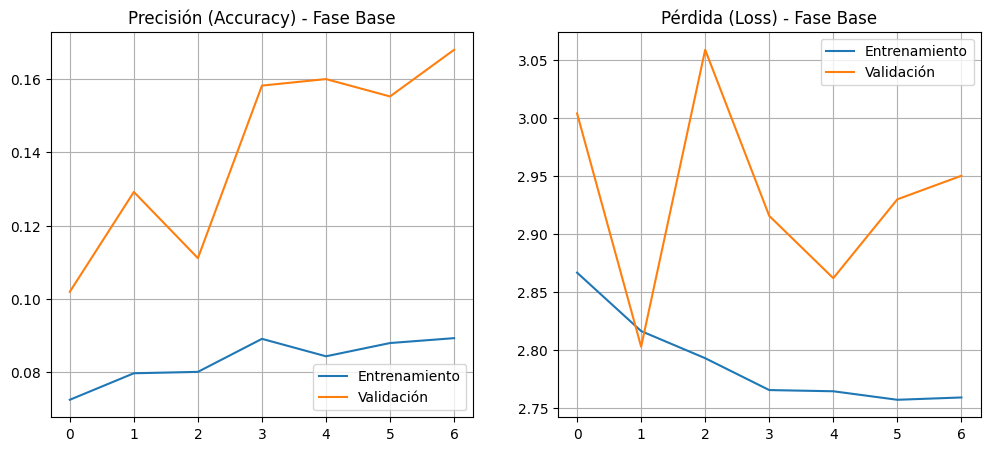

In [ ]:
# PASO 9: Visualización de las curvas de aprendizaje
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

# Gráfico de Precisión
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento')
plt.plot(val_acc, label='Validación')
plt.legend(loc='lower right')
plt.title('Precisión (Accuracy) - Fase Base')
plt.grid(True)

# Gráfico de Pérdida
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento')
plt.plot(val_loss, label='Validación')
plt.legend(loc='upper right')
plt.title('Pérdida (Loss) - Fase Base')
plt.grid(True)

plt.show()

In [ ]:
# PASO 9: (Continuación) Descongelamiento quirúrgico y Fine-Tuning

# 1. Descongelar el modelo base
base_model.trainable = True

# 2. Congelar todas las capas hasta el bloque 13 (Fine-tuning de capas altas)
# Esto preserva las características de bajo nivel (bordes, texturas)
# y re-entrena solo las capas de alto nivel (estructuras urbanas, vegetación específica).
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compilar el modelo con un Learning Rate muy bajo
# Es crucial reducir el LR para evitar destruir los pesos preentrenados.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modelo desbloqueado para Fine-Tuning (Capas superiores activas).")
model.summary()

✅ Modelo desbloqueado para Fine-Tuning (Capas superiores activas).


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 1,880,655 (7.17 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
# PASO 9: (Continuación) Ejecución del re-entrenamiento (Fine-Tuning)

# 1. Ajustamos la paciencia del EarlyStopping para el fine-tuning
# Al ser un ajuste más fino, no queremos esperar demasiado si el modelo empieza a divergir
fine_tuning_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

# 2. Iniciamos el entrenamiento de ajuste fino
print("🚀 Iniciando Fine-Tuning con Learning Rate 1e-5...")
history_fine = model.fit(
    train_ds_aug,
    epochs=10,
    validation_data=val_ds_preprocessed,
    callbacks=fine_tuning_callbacks
)

print("\n🎉 ¡Fine-Tuning completado con éxito!")

🚀 Iniciando Fine-Tuning con Learning Rate 1e-5...
Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 1596s 3s/step - accuracy: 0.0714 - loss: 2.8204 - val_accuracy: 0.1265 - val_loss: 2.7331
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 1610s 3s/step - accuracy: 0.0820 - loss: 2.7385 - val_accuracy: 0.1159 - val_loss: 2.7116
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 1512s 3s/step - accuracy: 0.0853 - loss: 2.7178 - val_accuracy: 0.1049 - val_loss: 2.7172
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 1623s 3s/step - accuracy: 0.0936 - loss: 2.6995 - val_accuracy: 0.1010 - val_loss: 2.7229
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 1542s 3s/step - accuracy: 0.0996 - loss: 2.6855 - val_accuracy: 0.1016 - val_loss: 2.7233
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

🎉 ¡Fine-Tuning completado con éxito!
